# 09 数据清洗与预处理策略（第3.4节）

目标：建立可复现的规则清洗流程，并输出"清洗前后对比 + 清洗统计 + 预处理特征"，可直接用于论文3.4节与后续建模。

## 简化清洗原则（当前版本）

仅使用放电阶段数据，并执行最小化清洗：
1. 仅保留 `discharge` 工况；
2. 仅对容量序列中的异常突变点进行清洗（鲁棒差分阈值法）；
3. 不再使用之前的硬规则/软规则组合约束。

说明：该策略用于尽量保留原始退化信息，仅剔除明显非物理跳变点。

In [1]:
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\\Users\\PLUTO\\Desktop\\battery-rul")
PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed'
CLEAN_ROOT = PROJECT_ROOT / 'data' / 'processed_clean'
FEATURE_ROOT = CLEAN_ROOT / 'features'
REPORT_ROOT = PROJECT_ROOT / 'results' / 'cleaning_reports'

for p in [CLEAN_ROOT, FEATURE_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.Transformer.data import default_condition_map
condition_map = default_condition_map()

print('PROJECT_ROOT =', PROJECT_ROOT)
print('PROCESSED_ROOT =', PROCESSED_ROOT)
print('CLEAN_ROOT =', CLEAN_ROOT)

PROJECT_ROOT = C:\Users\PLUTO\Desktop\battery-rul
PROCESSED_ROOT = C:\Users\PLUTO\Desktop\battery-rul\data\processed
CLEAN_ROOT = C:\Users\PLUTO\Desktop\battery-rul\data\processed_clean


In [2]:
# 扫描所有 pkl 文件（按相对路径保存，便于追溯）
pkl_files = sorted(PROCESSED_ROOT.rglob('*.pkl'))
battery_index = {}
for fp in pkl_files:
    battery_id = fp.stem
    battery_index[battery_id] = fp

print('发现 pkl 文件数:', len(pkl_files))
print('前10个电池ID:', sorted(list(battery_index.keys()))[:10])

发现 pkl 文件数: 38
前10个电池ID: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030']


In [15]:
def _to_1d_array(x):
    try:
        arr = np.asarray(x).reshape(-1)
        return arr
    except Exception:
        return np.array([])


def clean_discharge_df(df_raw, z_th=8.0):
    # 1) 仅保留放电数据
    if 'Cycle_Type' in df_raw.columns:
        df = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
    else:
        df = df_raw.copy()

    n_discharge_raw = int(len(df))
    if n_discharge_raw < 5 or 'Capacity' not in df.columns:
        stats = {
            'n_discharge_raw': n_discharge_raw,
            'n_after_discharge_only': n_discharge_raw,
            'n_removed_anomaly_points': 0,
            'n_final': n_discharge_raw,
        }
        return df, stats

    # 2) 仅做异常点清洗：对容量一阶差分做鲁棒Z分数阈值过滤
    cap = pd.to_numeric(df['Capacity'], errors='coerce').to_numpy()
    valid_mask = np.isfinite(cap)
    idx_valid = np.where(valid_mask)[0]

    if idx_valid.size < 5:
        stats = {
            'n_discharge_raw': n_discharge_raw,
            'n_after_discharge_only': n_discharge_raw,
            'n_removed_anomaly_points': 0,
            'n_final': n_discharge_raw,
        }
        return df, stats

    cap_valid = cap[valid_mask]
    d = np.diff(cap_valid)
    med = np.median(d)
    mad = np.median(np.abs(d - med)) + 1e-8
    robust_z = np.abs((d - med) / (1.4826 * mad))

    # 差分异常对应后一个点 i+1
    bad_local = np.where(robust_z > z_th)[0] + 1
    bad_global = idx_valid[bad_local] if bad_local.size > 0 else np.array([], dtype=int)

    keep_mask = np.ones(len(df), dtype=bool)
    keep_mask[bad_global] = False
    df_clean = df.loc[keep_mask].copy()

    stats = {
        'n_discharge_raw': n_discharge_raw,
        'n_after_discharge_only': n_discharge_raw,
        'n_removed_anomaly_points': int(len(bad_global)),
        'n_final': int(len(df_clean)),
    }

    return df_clean, stats

In [16]:
# 执行全量清洗并保存
report_rows = []
cleaned_data = {}

for battery_id, src_path in battery_index.items():
    df_raw = pd.read_pickle(src_path)
    df_clean, stats = clean_discharge_df(df_raw)

    # 按原目录相对结构保存
    rel_dir = src_path.parent.relative_to(PROCESSED_ROOT)
    out_dir = CLEAN_ROOT / rel_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{battery_id}.pkl'
    df_clean.to_pickle(out_path)

    cleaned_data[battery_id] = df_clean
    report_rows.append({
        'battery_id': battery_id,
        'src_path': str(src_path),
        'clean_path': str(out_path),
        **stats,
        'keep_ratio': (stats['n_final'] / stats['n_discharge_raw']) if stats['n_discharge_raw'] > 0 else np.nan,
    })

report_df = pd.DataFrame(report_rows).sort_values('battery_id').reset_index(drop=True)
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
report_csv = REPORT_ROOT / f'cleaning_report_{ts}.csv'
report_df.to_csv(report_csv, index=False, encoding='utf-8-sig')

print('清洗完成，电池数:', len(report_df))
print('报告已保存:', report_csv)
display(report_df.head())

清洗完成，电池数: 34
报告已保存: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\cleaning_report_20260327_173044.csv


,battery_id,src_path,clean_path,n_discharge_raw,n_after_discharge_only,n_removed_anomaly_points,n_final,keep_ratio
0,B0005,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,168,168,2,166,0.988095
1,B0006,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,168,168,4,164,0.976190
2,B0007,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,168,168,1,167,0.994048
3,B0018,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,132,132,5,127,0.962121
4,B0025,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,28,28,0,28,1.000000


In [17]:
# 全局统计（简化清洗口径）
global_stats = {
    '总电池数': int(len(report_df)),
    '放电原始样本总数': int(report_df['n_discharge_raw'].sum()),
    '仅保留放电后样本总数': int(report_df['n_after_discharge_only'].sum()),
    '异常点剔除总数': int(report_df['n_removed_anomaly_points'].sum()),
    '最终保留样本总数': int(report_df['n_final'].sum()),
    '平均保留率': float(report_df['keep_ratio'].mean()),
}

print('=== 全局清洗统计（仅放电+异常点）===')
for k, v in global_stats.items():
    if isinstance(v, float):
        print(f'{k}: {v:.4f}')
    else:
        print(f'{k}: {v}')

print('\n按保留率最低的10块电池（重点检查对象）：')
display(report_df.sort_values('keep_ratio').head(10)[['battery_id', 'n_discharge_raw', 'n_final', 'keep_ratio']])

=== 全局清洗统计（仅放电+异常点）===
总电池数: 34
放电原始样本总数: 2794
仅保留放电后样本总数: 2794
异常点剔除总数: 141
最终保留样本总数: 2653
平均保留率: 0.9385

按保留率最低的10块电池（重点检查对象）：


,battery_id,n_discharge_raw,n_final,keep_ratio
18,B0041,67,41,0.611940
26,B0049,25,20,0.800000
28,B0051,25,20,0.800000
16,B0039,47,41,0.872340
17,B0040,47,41,0.872340
24,B0047,72,64,0.888889
5,B0026,28,25,0.892857
25,B0048,72,65,0.902778
23,B0046,72,65,0.902778
15,B0038,47,43,0.914894


In [11]:
# 低可信电池识别（用于主实验剔除与附录对照）
qc_df = report_df.copy()
qc_df['removed_count'] = qc_df['n_discharge_raw'] - qc_df['n_final']
qc_df['flag_low_final_cycles'] = qc_df['n_final'] < 40
qc_df['flag_low_keep_ratio'] = qc_df['keep_ratio'] < 0.60
qc_df['flag_too_many_removed'] = qc_df['removed_count'] > 25
qc_df['flag_low_confidence'] = qc_df[[
    'flag_low_final_cycles',
    'flag_low_keep_ratio',
    'flag_too_many_removed',
]].any(axis=1)

low_conf_df = qc_df[qc_df['flag_low_confidence']].sort_values(
    ['keep_ratio', 'n_final', 'removed_count'],
    ascending=[True, True, False]
).reset_index(drop=True)

print('低可信电池数量:', len(low_conf_df))
display(low_conf_df[[
    'battery_id', 'n_discharge_raw', 'n_final', 'removed_count', 'keep_ratio',
    'flag_low_final_cycles', 'flag_low_keep_ratio', 'flag_too_many_removed'
]].head(20))

focus_ids = ['B0038', 'B0052']
focus_df = qc_df[qc_df['battery_id'].isin(focus_ids)].copy()
print('\n重点关注电池（B0038/B0052）:')
display(focus_df[[
    'battery_id', 'n_discharge_raw', 'n_final', 'removed_count', 'keep_ratio',
    'flag_low_final_cycles', 'flag_low_keep_ratio', 'flag_too_many_removed', 'flag_low_confidence'
]].sort_values('battery_id'))

low_conf_ids = low_conf_df['battery_id'].tolist()
print('\n建议主实验排除名单（可用于附录对照）:', low_conf_ids)

低可信电池数量: 12


,battery_id,n_discharge_raw,n_final,removed_count,keep_ratio,flag_low_final_cycles,flag_low_keep_ratio,flag_too_many_removed
0,B0052,25,4,21,0.160000,True,True,False
1,B0041,67,25,42,0.373134,True,True,True
2,B0042,112,65,47,0.580357,False,True,True
3,B0043,112,65,47,0.580357,False,True,True
4,B0044,112,65,47,0.580357,False,True,True
5,B0050,25,15,10,0.600000,True,False,False
6,B0049,25,24,1,0.960000,True,False,False
7,B0051,25,24,1,0.960000,True,False,False
8,B0025,28,28,0,1.000000,True,False,False
9,B0026,28,28,0,1.000000,True,False,False



重点关注电池（B0038/B0052）:


,battery_id,n_discharge_raw,n_final,removed_count,keep_ratio,flag_low_final_cycles,flag_low_keep_ratio,flag_too_many_removed,flag_low_confidence
15,B0038,47,47,0,1.00,False,False,False,False
29,B0052,25,4,21,0.16,True,True,False,True



建议主实验排除名单（可用于附录对照）: ['B0052', 'B0041', 'B0042', 'B0043', 'B0044', 'B0050', 'B0049', 'B0051', 'B0025', 'B0026', 'B0027', 'B0028']


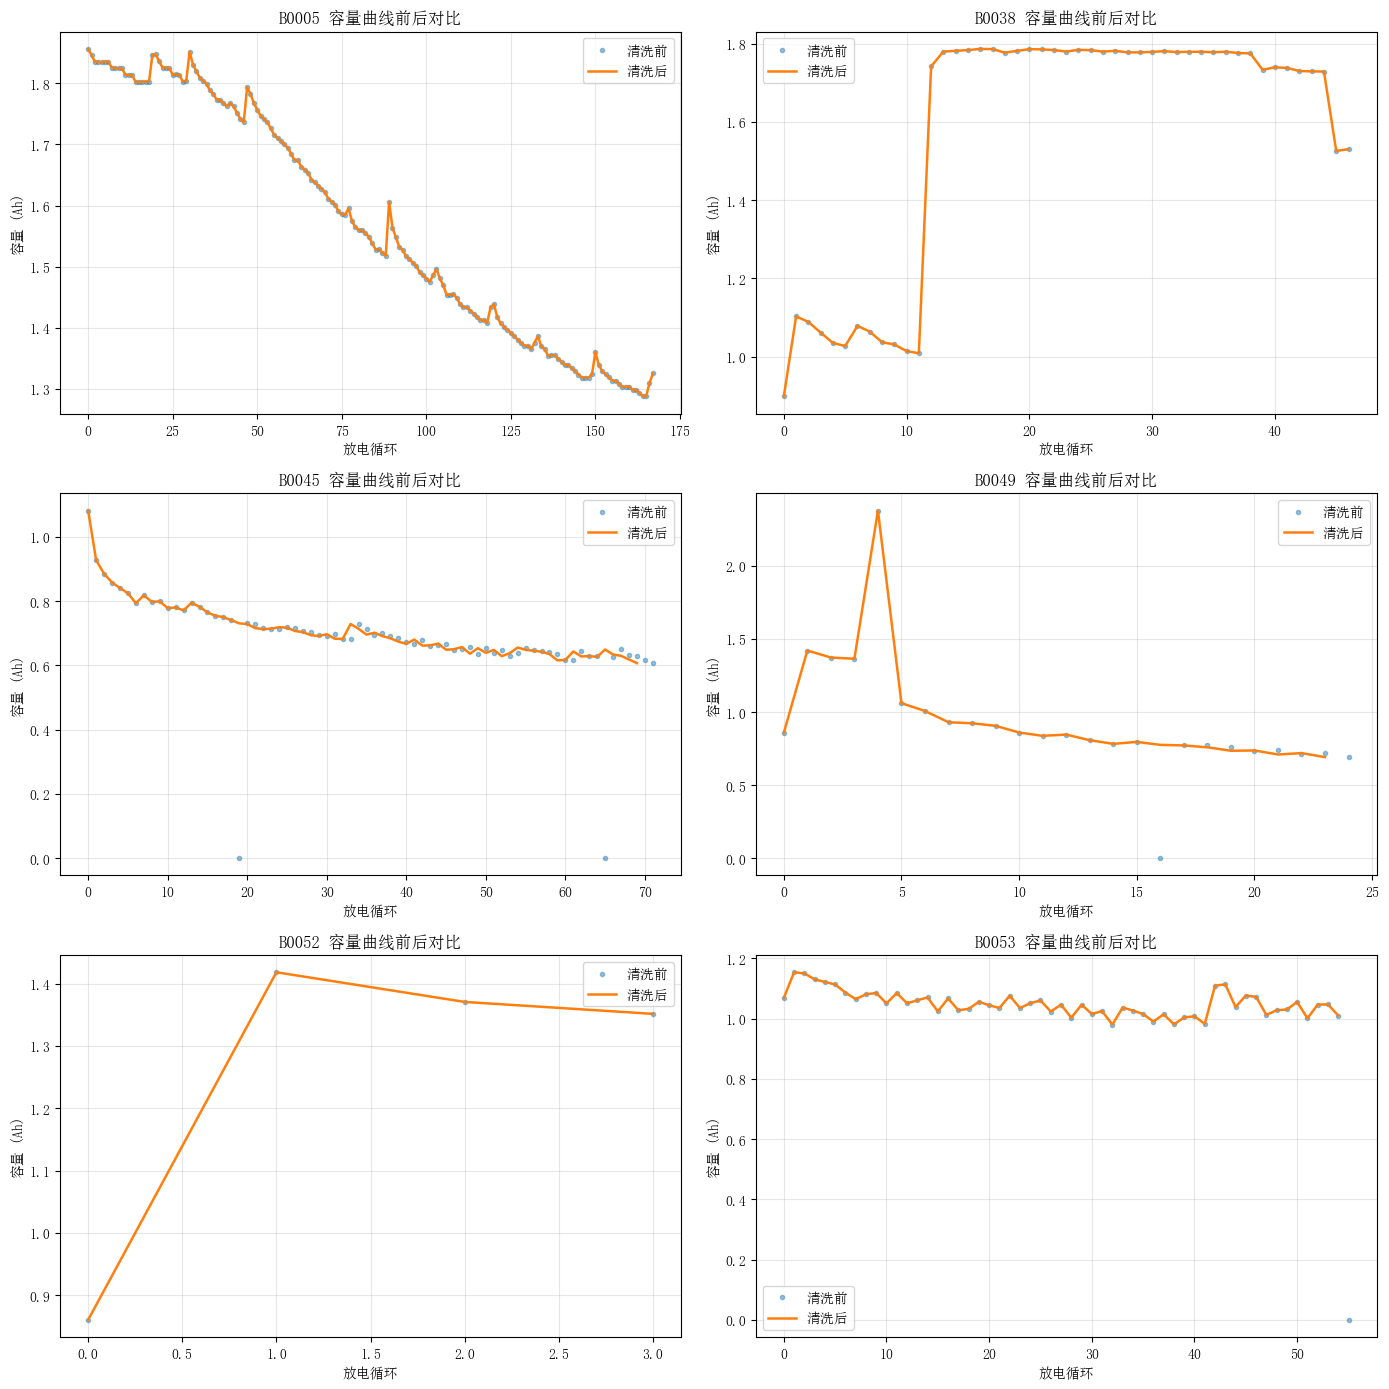

对比图已保存: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\cleaning_before_after_20260327_162526.png


In [8]:
# 清洗前后对比图（可用于论文图）
plt.rcParams['font.sans-serif'] = ['SimSun', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

compare_ids = ['B0005', 'B0038', 'B0045', 'B0049', 'B0052', 'B0053']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, bid in zip(axes, compare_ids):
    if bid not in battery_index:
        ax.set_title(f'{bid} (文件缺失)')
        ax.axis('off')
        continue

    df_raw = pd.read_pickle(battery_index[bid])
    if 'Cycle_Type' in df_raw.columns:
        df_raw = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()

    raw_cap = pd.to_numeric(df_raw.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy()
    clean_cap = cleaned_data.get(bid, pd.DataFrame()).get('Capacity', pd.Series(dtype=float)).to_numpy(dtype=float)

    ax.plot(raw_cap, '.', alpha=0.45, label='清洗前')
    ax.plot(clean_cap, '-', linewidth=1.8, label='清洗后')
    ax.set_title(f'{bid} 容量曲线前后对比')
    ax.set_xlabel('放电循环')
    ax.set_ylabel('容量 (Ah)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
fig_path = REPORT_ROOT / f"cleaning_before_after_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print('对比图已保存:', fig_path)

In [12]:
# 曲线形态异常检测（识别“样本量正常但曲线诡异”的电池）
shape_rows = []

for bid, src_path in battery_index.items():
    df_raw = pd.read_pickle(src_path)
    if 'Cycle_Type' in df_raw.columns:
        df_raw = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
    cap = pd.to_numeric(df_raw.get('Capacity', pd.Series(dtype=float)), errors='coerce').dropna().to_numpy()
    cap = cap[np.isfinite(cap)]
    if cap.size < 5:
        continue

    d = np.diff(cap)
    med = np.median(d)
    mad = np.median(np.abs(d - med)) + 1e-8
    robust_z = np.abs((d - med) / (1.4826 * mad))

    # 经验特征：容量反弹比例、突变比例、最大鲁棒Z值
    rebound_ratio = float(np.mean(d > 0.01))
    jump_ratio = float(np.mean(np.abs(d) > 0.04))
    max_robust_z = float(np.max(robust_z))

    shape_rows.append({
        'battery_id': bid,
        'n_points': int(cap.size),
        'rebound_ratio': rebound_ratio,
        'jump_ratio': jump_ratio,
        'max_robust_z': max_robust_z,
    })

shape_df = pd.DataFrame(shape_rows)
shape_df['flag_shape_anomaly'] = (
    (shape_df['rebound_ratio'] > 0.20)
    | (shape_df['jump_ratio'] > 0.20)
    | (shape_df['max_robust_z'] > 8.0)
)

print('形态异常候选数量:', int(shape_df['flag_shape_anomaly'].sum()))
display(shape_df.sort_values(
    ['flag_shape_anomaly', 'max_robust_z', 'jump_ratio', 'rebound_ratio'],
    ascending=[False, False, False, False]
).head(15))

print('\nB0038 / B0052 形态指标:')
display(shape_df[shape_df['battery_id'].isin(['B0038', 'B0052'])].sort_values('battery_id'))

形态异常候选数量: 30


,battery_id,n_points,rebound_ratio,jump_ratio,max_robust_z,flag_shape_anomaly
18,B0041,67,0.060606,0.045455,2660.806026,True
17,B0040,47,0.108696,0.108696,301.210294,True
16,B0039,47,0.086957,0.130435,266.692146,True
19,B0042,112,0.099099,0.045045,266.240098,True
20,B0043,112,0.099099,0.036036,209.329812,True
23,B0046,72,0.112676,0.140845,171.682281,True
21,B0044,112,0.135135,0.036036,162.189491,True
15,B0038,47,0.086957,0.108696,141.036495,True
14,B0036,197,0.107143,0.030612,134.566350,True
24,B0047,72,0.098592,0.140845,130.023331,True



B0038 / B0052 形态指标:


,battery_id,n_points,rebound_ratio,jump_ratio,max_robust_z,flag_shape_anomaly
15,B0038,47,0.086957,0.108696,141.036495,True


## 3.4 规则清单与主实验矩阵（简化口径）

### 规则清单（Main Experiment）
1. 数据范围：仅使用放电（discharge）阶段数据；
2. 清洗策略：仅进行异常点清洗（鲁棒差分阈值法）；
3. 不再使用此前硬规则/软规则组合；
4. 分组与电池筛选按主实验矩阵执行；
5. 透明性要求：输出电池级纳入/排除清单与清洗前后样本量，便于复核。

### 实验矩阵（训练材料配置）
- 室温模型训练：G1 + G2 + G4。
- 高温模型训练：G3。
- 低温模型训练：G7 + G9（G9不含B0053）。

In [18]:
# 生成主实验纳入清单、实验矩阵表与主实验特征表（仅放电+异常点清洗口径）

# 组定义（与当前分组图一致）
group_to_batteries = {
    'G1': ['B0005', 'B0006', 'B0007', 'B0018'],
    'G2': ['B0025', 'B0026', 'B0027', 'B0028'],
    'G3': ['B0029', 'B0030', 'B0031', 'B0032'],
    'G4': ['B0033', 'B0034', 'B0036', 'B0038'],
    'G5': ['B0039', 'B0040', 'B0041'],
    'G6': ['B0042', 'B0043', 'B0044'],
    'G7': ['B0045', 'B0046', 'B0047', 'B0048'],
    'G8': ['B0049', 'B0050', 'B0051', 'B0052'],
    'G9': ['B0053', 'B0054', 'B0055', 'B0056'],
}

temp_zone_map = {
    'G1': 'room', 'G2': 'room', 'G4': 'room',
    'G3': 'high',
    'G7': 'low', 'G9': 'low',
}

selected_groups = set(temp_zone_map.keys())

# 反向索引
battery_to_group = {}
for g, bids in group_to_batteries.items():
    for bid in bids:
        battery_to_group[bid] = g

main_cleaned_data = {}
manifest_rows = []

for bid, df in cleaned_data.items():
    g = battery_to_group.get(bid, 'UNKNOWN')
    in_selected_group = g in selected_groups
    selected = in_selected_group
    exclusion_reason = ''
    n_before = int(len(df))
    n_after = int(len(df))

    if not in_selected_group:
        selected = False
        exclusion_reason = 'group_not_selected'

    # 按主实验决策剔除B0053
    if selected and g == 'G9' and bid == 'B0053':
        selected = False
        exclusion_reason = 'exclude_B0053_in_G9'

    if selected:
        main_cleaned_data[bid] = df.copy()

    manifest_rows.append({
        'battery_id': bid,
        'group_id': g,
        'temp_zone': temp_zone_map.get(g, 'unused'),
        'selected_for_main_experiment': bool(selected),
        'exclusion_reason': exclusion_reason,
        'n_before_plan': n_before,
        'n_after_plan': n_after,
        'removed_by_plan': int(n_before - n_after),
        'keep_ratio_plan': (n_after / n_before) if n_before > 0 else np.nan,
    })

manifest_df = pd.DataFrame(manifest_rows).sort_values(['group_id', 'battery_id']).reset_index(drop=True)

matrix_rows = []
for g in sorted(group_to_batteries.keys()):
    matrix_rows.append({
        'group_id': g,
        'temp_zone': temp_zone_map.get(g, 'unused'),
        'batteries': ','.join(group_to_batteries[g]),
        'used_in_main_experiment': g in selected_groups,
        'special_rule': 'remove_B0053' if g == 'G9' else 'none',
    })
matrix_df = pd.DataFrame(matrix_rows)

ts_main = datetime.now().strftime('%Y%m%d_%H%M%S')
manifest_path = REPORT_ROOT / f'main_experiment_manifest_{ts_main}.csv'
matrix_path = REPORT_ROOT / f'main_experiment_matrix_{ts_main}.csv'
manifest_df.to_csv(manifest_path, index=False, encoding='utf-8-sig')
matrix_df.to_csv(matrix_path, index=False, encoding='utf-8-sig')

# 导出主实验特征表
main_feature_rows = []
for bid, df in main_cleaned_data.items():
    cond = condition_map.get(bid, {})
    for _, row in df.iterrows():
        t_arr = np.asarray(row.get('Time', [])).reshape(-1)
        tp_arr = np.asarray(row.get('Temperature_measured', [])).reshape(-1)
        if len(t_arr) == 0 or len(tp_arr) == 0:
            continue
        main_feature_rows.append({
            'battery_id': bid,
            'group_id': battery_to_group.get(bid, 'UNKNOWN'),
            'temp_zone': temp_zone_map.get(battery_to_group.get(bid, 'UNKNOWN'), 'unused'),
            'cycle_index': row.get('Specific_Index', np.nan),
            'discharge_time': float(t_arr[-1]),
            'max_temp': float(np.max(tp_arr)),
            'ambient_temp_c': float(cond.get('ambient_temp_c', np.nan)),
            'discharge_current_a': float(cond.get('discharge_current_a', np.nan)),
            'cutoff_voltage_v': float(cond.get('cutoff_voltage_v', np.nan)),
            'capacity': float(row.get('Capacity', np.nan)),
        })

main_feature_df = pd.DataFrame(main_feature_rows)
main_feature_path = FEATURE_ROOT / f'main_experiment_feature_table_{ts_main}.csv'
main_feature_df.to_csv(main_feature_path, index=False, encoding='utf-8-sig')

print('主实验纳入电池数:', int(manifest_df['selected_for_main_experiment'].sum()))
print('主实验特征行数:', len(main_feature_df))
print('纳入清单:', manifest_path)
print('实验矩阵:', matrix_path)
print('主实验特征表:', main_feature_path)

print('\n主实验排除电池:')
display(manifest_df.loc[~manifest_df['selected_for_main_experiment'], ['battery_id', 'group_id', 'exclusion_reason']])

print('\n主实验各温区样本统计:')
display(main_feature_df.groupby('temp_zone')['battery_id'].count().reset_index(name='n_samples'))

主实验纳入电池数: 23
主实验特征行数: 2062
纳入清单: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_experiment_manifest_20260327_173051.csv
实验矩阵: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_experiment_matrix_20260327_173051.csv
主实验特征表: C:\Users\PLUTO\Desktop\battery-rul\data\processed_clean\features\main_experiment_feature_table_20260327_173051.csv

主实验排除电池:


,battery_id,group_id,exclusion_reason
16,B0039,G5,group_not_selected
17,B0040,G5,group_not_selected
18,B0041,G5,group_not_selected
19,B0042,G6,group_not_selected
20,B0043,G6,group_not_selected
21,B0044,G6,group_not_selected
26,B0049,G8,group_not_selected
27,B0050,G8,group_not_selected
28,B0051,G8,group_not_selected
29,B0052,G8,group_not_selected



主实验各温区样本统计:


,temp_zone,n_samples
0,high,156
1,low,564
2,room,1342


In [9]:
# 预处理：提取统一标量特征并保存（给后续模型直接用）
feature_rows = []

for battery_id, df in cleaned_data.items():
    cond = condition_map.get(battery_id, {})
    for _, row in df.iterrows():
        time_arr = np.asarray(row.get('Time', [])).reshape(-1)
        temp_arr = np.asarray(row.get('Temperature_measured', [])).reshape(-1)
        if len(time_arr) == 0 or len(temp_arr) == 0:
            continue

        feature_rows.append({
            'battery_id': battery_id,
            'cycle_index': row.get('Specific_Index', np.nan),
            'discharge_time': float(time_arr[-1]),
            'max_temp': float(np.max(temp_arr)),
            'ambient_temp_c': float(cond.get('ambient_temp_c', np.nan)),
            'discharge_current_a': float(cond.get('discharge_current_a', np.nan)),
            'cutoff_voltage_v': float(cond.get('cutoff_voltage_v', np.nan)),
            'capacity': float(row.get('Capacity', np.nan)),
        })

feature_df = pd.DataFrame(feature_rows)
feature_path = FEATURE_ROOT / f"cleaned_feature_table_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
feature_df.to_csv(feature_path, index=False, encoding='utf-8-sig')

print('特征表行数:', len(feature_df))
print('特征表已保存:', feature_path)
display(feature_df.head())

特征表行数: 2562
特征表已保存: C:\Users\PLUTO\Desktop\battery-rul\data\processed_clean\features\cleaned_feature_table_20260327_162527.csv


,battery_id,cycle_index,discharge_time,max_temp,ambient_temp_c,discharge_current_a,cutoff_voltage_v,capacity
0,B0005,1,3690.234,38.982181,24.0,2.0,2.7,1.856487
1,B0005,2,3672.344,39.033398,24.0,2.0,2.7,1.846327
2,B0005,3,3651.641,38.818797,24.0,2.0,2.7,1.835349
3,B0005,4,3631.563,38.762305,24.0,2.0,2.7,1.835263
4,B0005,5,3629.172,38.665393,24.0,2.0,2.7,1.834646


## 增强清洗方案（仅放电 + 局部鲁棒异常检测）

在“仅保留放电数据”的前提下，进一步采用双重鲁棒检测：
1. 局部水平异常：滚动中位数 + MAD，剔除明显偏离局部趋势的容量点；
2. 差分突变异常：对一阶差分做鲁棒Z分数检测，剔除非物理突变点。

该方法相比仅用单一差分阈值更稳健，能够同时处理“离群尖点”和“突变跳点”。

In [13]:
# 增强清洗：仅放电 + 局部中位数MAD + 差分鲁棒Z（按循环索引排序）
CLEAN_ADV_ROOT = PROJECT_ROOT / 'data' / 'processed_clean_advanced'
FEATURE_ADV_ROOT = CLEAN_ADV_ROOT / 'features'
REPORT_ADV_ROOT = REPORT_ROOT
for p in [CLEAN_ADV_ROOT, FEATURE_ADV_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

def _sort_discharge_df(df):
    if 'Specific_Index' in df.columns:
        sidx = pd.to_numeric(df['Specific_Index'], errors='coerce')
        if sidx.notna().sum() > 0:
            tmp = df.copy()
            tmp['_sidx_num'] = sidx
            tmp = tmp.sort_values('_sidx_num').drop(columns=['_sidx_num'])
            return tmp.reset_index(drop=True)
    return df.reset_index(drop=True)

def clean_discharge_df_advanced(
    df_raw,
    diff_z_th=8.0,
    level_k=6.0,
    win=9,
    pit_max_gap=12,
    low_drop_abs_th=0.08,
    low_floor_abs_th=0.20,
):
    if 'Cycle_Type' in df_raw.columns:
        df = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
    else:
        df = df_raw.copy()
    df = _sort_discharge_df(df)

    n_discharge_raw = int(len(df))
    if n_discharge_raw < 7 or 'Capacity' not in df.columns:
        stats = {
            'n_discharge_raw': n_discharge_raw,
            'n_removed_level_outliers': 0,
            'n_removed_diff_spikes': 0,
            'n_removed_low_pit_points': 0,
            'n_removed_low_floor_points': 0,
            'n_removed_union': 0,
            'n_final': n_discharge_raw,
        }
        return df, stats

    cap = pd.to_numeric(df['Capacity'], errors='coerce').to_numpy(dtype=float)
    valid_mask = np.isfinite(cap)
    idx_valid = np.where(valid_mask)[0]
    if idx_valid.size < 7:
        stats = {
            'n_discharge_raw': n_discharge_raw,
            'n_removed_level_outliers': 0,
            'n_removed_diff_spikes': 0,
            'n_removed_low_pit_points': 0,
            'n_removed_low_floor_points': 0,
            'n_removed_union': 0,
            'n_final': n_discharge_raw,
        }
        return df, stats

    cap_valid = cap[valid_mask]
    s = pd.Series(cap_valid)

    # 1) 局部水平异常：rolling median + MAD
    roll_med = s.rolling(window=win, center=True, min_periods=max(3, win // 2)).median()
    abs_dev = (s - roll_med).abs()
    roll_mad = abs_dev.rolling(window=win, center=True, min_periods=max(3, win // 2)).median()
    roll_med = roll_med.bfill().ffill().fillna(s.median())
    roll_mad = roll_mad.bfill().ffill().fillna(roll_mad.median()) + 1e-8
    level_outlier_local = (s - roll_med).abs() > (level_k * 1.4826 * roll_mad)

    # 2) 差分突变异常：robust z on first-order diff
    d = np.diff(cap_valid)
    med = np.median(d)
    mad = np.median(np.abs(d - med)) + 1e-8
    rz = np.abs((d - med) / (1.4826 * mad))

    # 仅剔除“跳变中更低的端点”，避免误删平台段正常点
    diff_outlier_local = np.zeros_like(cap_valid, dtype=bool)
    bad_diff_idx = np.where(rz > diff_z_th)[0]
    for i in bad_diff_idx:
        if d[i] >= 0:
            diff_outlier_local[i] = True
        else:
            diff_outlier_local[i + 1] = True

    # 3) 连续低谷补充检测：识别“急降后短期回升”的整段低谷并整段剔除
    low_pit_local = np.zeros_like(cap_valid, dtype=bool)
    down_idx = bad_diff_idx[d[bad_diff_idx] < 0] if bad_diff_idx.size > 0 else np.array([], dtype=int)
    up_idx = bad_diff_idx[d[bad_diff_idx] > 0] if bad_diff_idx.size > 0 else np.array([], dtype=int)
    if down_idx.size > 0 and up_idx.size > 0:
        for di in down_idx:
            cand_up = up_idx[up_idx > di]
            if cand_up.size == 0:
                continue
            uj = cand_up[0]
            if (uj - di) <= pit_max_gap:
                seg = np.arange(di + 1, uj + 1, dtype=int)
                if seg.size == 0:
                    continue
                seg_vals = cap_valid[seg]
                left_val = cap_valid[di]
                right_val = cap_valid[min(uj + 1, len(cap_valid) - 1)]
                ref_val = min(left_val, right_val)
                if (ref_val - float(np.nanmin(seg_vals))) > low_drop_abs_th:
                    low_pit_local[seg] = True

    # 4) 宽窗口基线下限规则：防止短窗口被低谷本身拉低导致漏检
    wide_win = max(21, win * 3)
    roll_med_wide = s.rolling(window=wide_win, center=True, min_periods=max(5, win)).median()
    roll_med_wide = roll_med_wide.bfill().ffill().fillna(s.median())
    low_floor_local = ((roll_med_wide - s) > low_floor_abs_th).to_numpy()

    union_local = np.asarray(level_outlier_local) | diff_outlier_local | low_pit_local | low_floor_local
    union_global = idx_valid[union_local] if union_local.any() else np.array([], dtype=int)

    keep_mask = np.ones(len(df), dtype=bool)
    keep_mask[union_global] = False
    df_clean = df.loc[keep_mask].copy().reset_index(drop=True)

    stats = {
        'n_discharge_raw': n_discharge_raw,
        'n_removed_level_outliers': int(np.asarray(level_outlier_local).sum()),
        'n_removed_diff_spikes': int(diff_outlier_local.sum()),
        'n_removed_low_pit_points': int(low_pit_local.sum()),
        'n_removed_low_floor_points': int(low_floor_local.sum()),
        'n_removed_union': int(union_local.sum()),
        'n_final': int(len(df_clean)),
    }
    return df_clean, stats

# 全量执行增强清洗并落盘
report_adv_rows = []
cleaned_data_adv = {}

for battery_id, src_path in battery_index.items():
    df_raw = pd.read_pickle(src_path)
    df_clean_adv, stats_adv = clean_discharge_df_advanced(df_raw)

    rel_dir = src_path.parent.relative_to(PROCESSED_ROOT)
    out_dir = CLEAN_ADV_ROOT / rel_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{battery_id}.pkl'
    df_clean_adv.to_pickle(out_path)

    cleaned_data_adv[battery_id] = df_clean_adv
    report_adv_rows.append({
        'battery_id': battery_id,
        'src_path': str(src_path),
        'clean_adv_path': str(out_path),
        **stats_adv,
        'keep_ratio': (stats_adv['n_final'] / stats_adv['n_discharge_raw']) if stats_adv['n_discharge_raw'] > 0 else np.nan,
    })

report_adv_df = pd.DataFrame(report_adv_rows).sort_values('battery_id').reset_index(drop=True)
ts_adv = datetime.now().strftime('%Y%m%d_%H%M%S')
report_adv_csv = REPORT_ADV_ROOT / f'cleaning_report_advanced_{ts_adv}.csv'
report_adv_df.to_csv(report_adv_csv, index=False, encoding='utf-8-sig')

print('增强清洗完成，电池数:', len(report_adv_df))
print('增强清洗报告:', report_adv_csv)
print('平均保留率:', f"{report_adv_df['keep_ratio'].mean():.4f}")
display(report_adv_df.head())

增强清洗完成，电池数: 34
增强清洗报告: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\cleaning_report_advanced_20260330_100442.csv
平均保留率: 0.8556


,battery_id,src_path,clean_adv_path,n_discharge_raw,n_removed_level_outliers,n_removed_diff_spikes,n_removed_low_pit_points,n_removed_low_floor_points,n_removed_union,n_final,keep_ratio
0,B0005,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,168,23,2,0,0,25,143,0.851190
1,B0006,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,168,14,4,0,0,18,150,0.892857
2,B0007,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,168,23,1,0,0,24,144,0.857143
3,B0018,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,132,0,5,0,0,5,127,0.962121
4,B0025,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,C:\Users\PLUTO\Desktop\battery-rul\data\proces...,28,1,0,0,0,1,27,0.964286


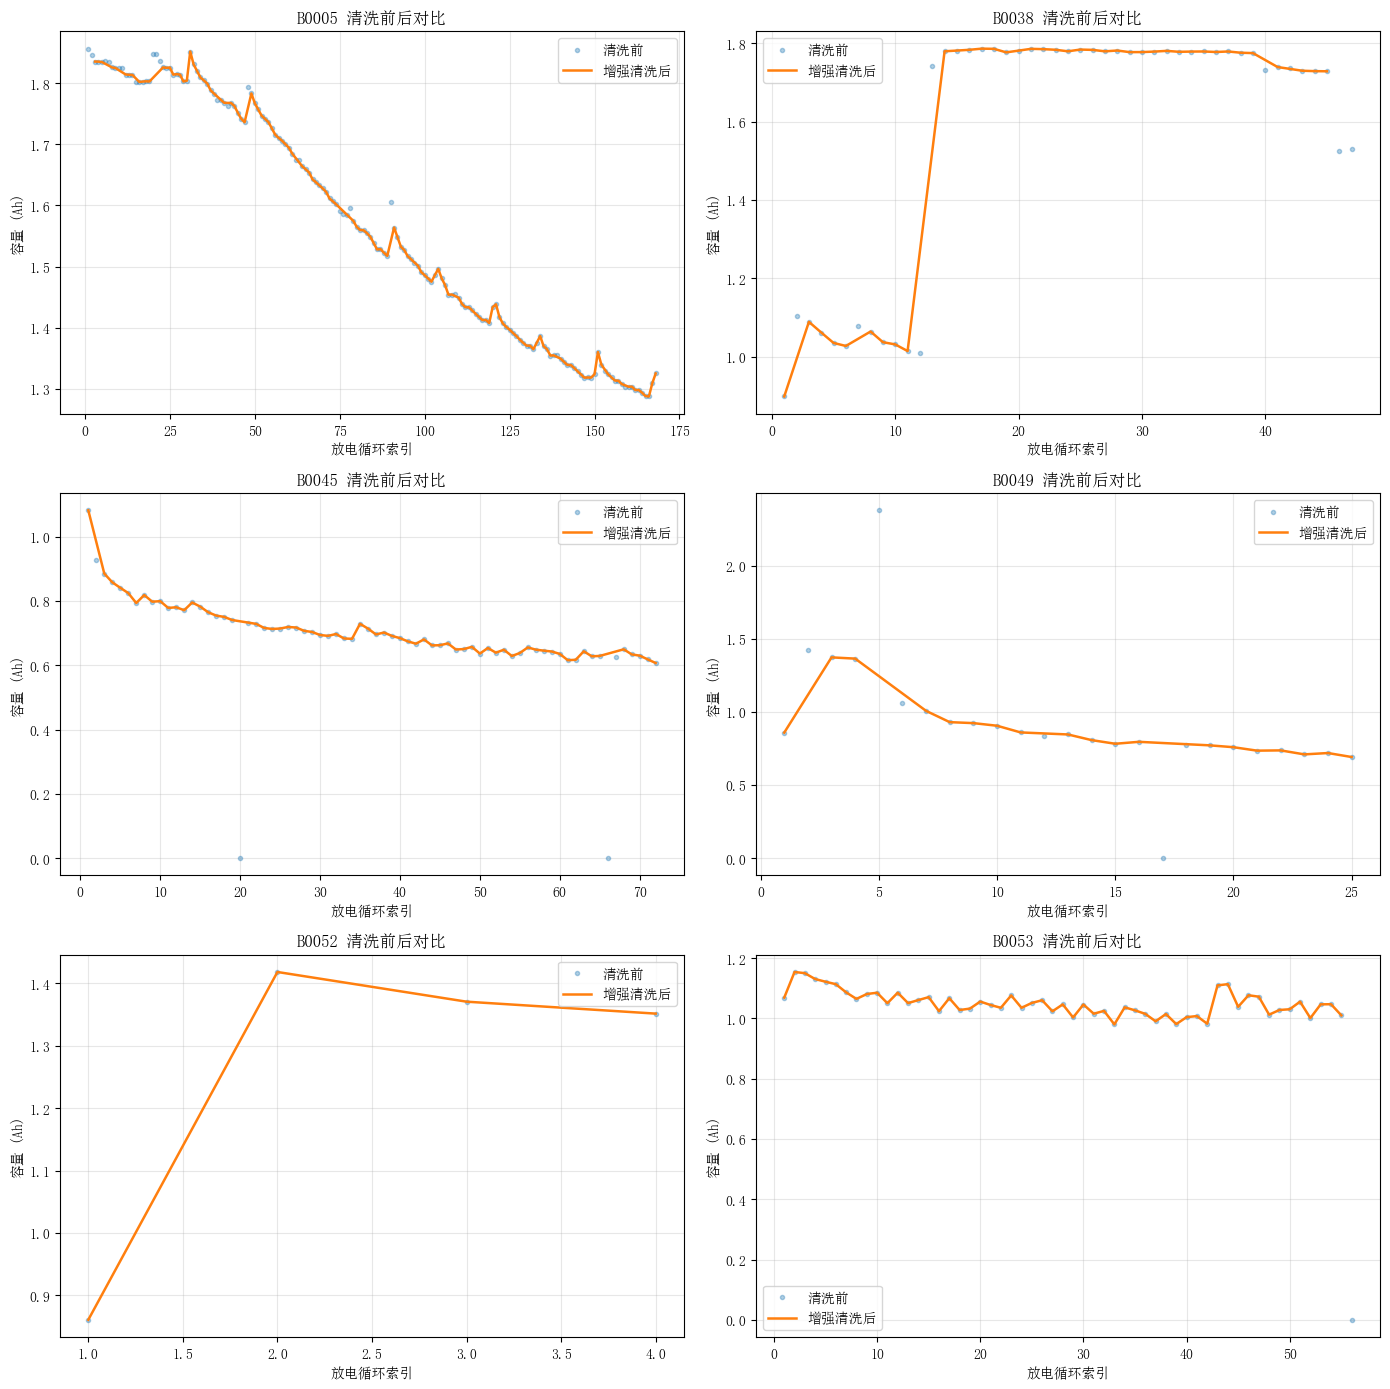

增强清洗对比图已保存: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\cleaning_before_after_advanced_20260330_090228.png

增强清洗移除点最多的10块电池:


,battery_id,n_discharge_raw,n_final,keep_ratio,removed
18,B0041,67,36,0.537313,31
0,B0005,168,143,0.851190,25
2,B0007,168,145,0.863095,23
20,B0043,112,90,0.803571,22
21,B0044,112,91,0.812500,21
19,B0042,112,94,0.839286,18
1,B0006,168,151,0.898810,17
12,B0033,197,181,0.918782,16
16,B0039,47,33,0.702128,14
17,B0040,47,37,0.787234,10


In [6]:
# 增强清洗前后对比图（按循环索引绘制）
plt.rcParams['font.sans-serif'] = ['SimSun', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

compare_ids_adv = ['B0005', 'B0038', 'B0045', 'B0049', 'B0052', 'B0053']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, bid in zip(axes, compare_ids_adv):
    if bid not in battery_index:
        ax.set_title(f'{bid} (文件缺失)')
        ax.axis('off')
        continue

    df_raw = pd.read_pickle(battery_index[bid])
    if 'Cycle_Type' in df_raw.columns:
        df_raw = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
    df_raw = _sort_discharge_df(df_raw)

    raw_cap = pd.to_numeric(df_raw.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
    if 'Specific_Index' in df_raw.columns:
        raw_x = pd.to_numeric(df_raw['Specific_Index'], errors='coerce').to_numpy(dtype=float)
    else:
        raw_x = np.arange(len(raw_cap), dtype=float)

    df_adv = cleaned_data_adv.get(bid, pd.DataFrame()).copy()
    df_adv = _sort_discharge_df(df_adv) if len(df_adv) > 0 else df_adv
    adv_cap = pd.to_numeric(df_adv.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
    if len(df_adv) > 0 and 'Specific_Index' in df_adv.columns:
        adv_x = pd.to_numeric(df_adv['Specific_Index'], errors='coerce').to_numpy(dtype=float)
    else:
        adv_x = np.arange(len(adv_cap), dtype=float)

    ax.plot(raw_x, raw_cap, '.', alpha=0.35, label='清洗前')
    ax.plot(adv_x, adv_cap, '-', linewidth=1.8, label='增强清洗后')
    ax.set_title(f'{bid} 清洗前后对比')
    ax.set_xlabel('放电循环索引')
    ax.set_ylabel('容量 (Ah)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
fig_adv_path = REPORT_ADV_ROOT / f"cleaning_before_after_advanced_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(fig_adv_path, dpi=300, bbox_inches='tight')
plt.show()
print('增强清洗对比图已保存:', fig_adv_path)

# 输出变化最大的电池，便于论文讨论
delta_df = report_adv_df[['battery_id', 'n_discharge_raw', 'n_final', 'keep_ratio']].copy()
delta_df['removed'] = delta_df['n_discharge_raw'] - delta_df['n_final']
print('\n增强清洗移除点最多的10块电池:')
display(delta_df.sort_values(['removed', 'keep_ratio'], ascending=[False, True]).head(10))

主实验训练电池数量: 23


,temp_zone,n_batteries
0,high,4
1,low,7
2,room,12


,battery_id,temp_zone,n_raw_discharge,n_clean_discharge,keep_ratio
0,B0005,room,168,143,0.851190
1,B0006,room,168,151,0.898810
2,B0007,room,168,145,0.863095
3,B0018,room,132,127,0.962121
4,B0025,room,28,27,0.964286
5,B0026,room,28,23,0.821429
6,B0027,room,28,27,0.964286
7,B0028,room,28,24,0.857143
8,B0033,room,197,181,0.918782
9,B0034,room,197,189,0.959391


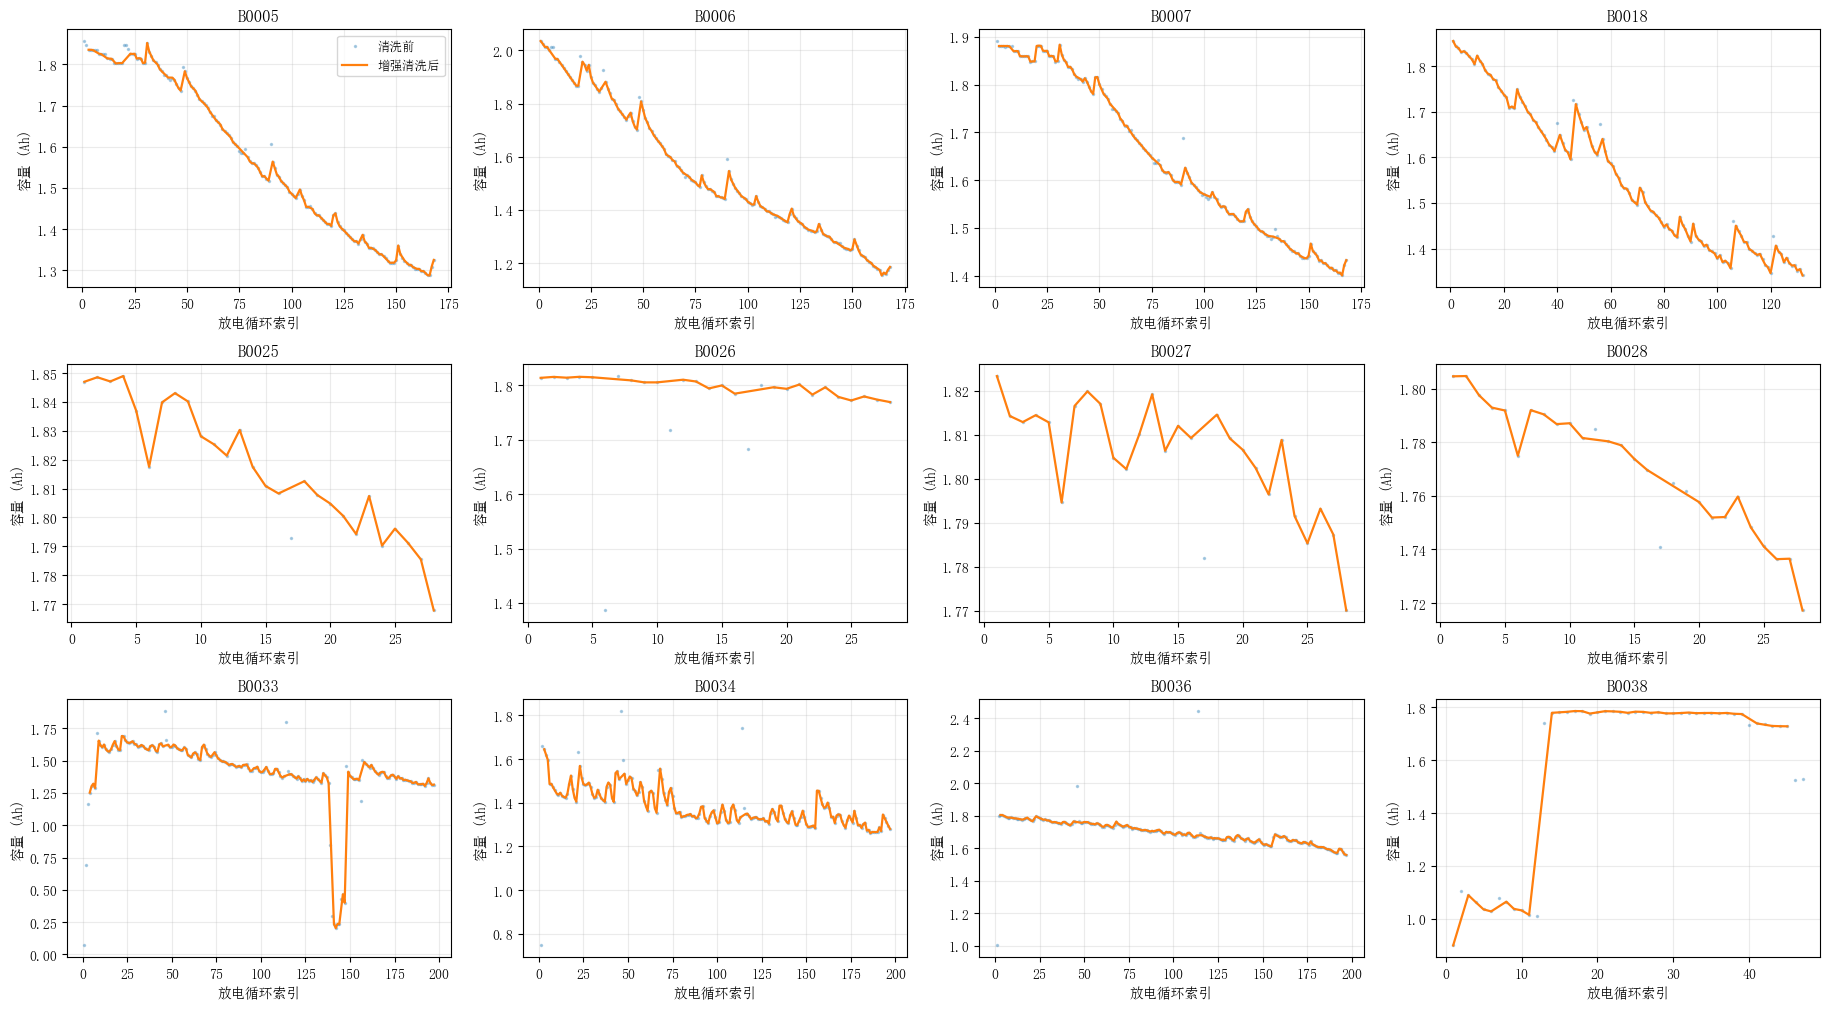

room 温区对比图已保存: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_room_20260330_090956.png


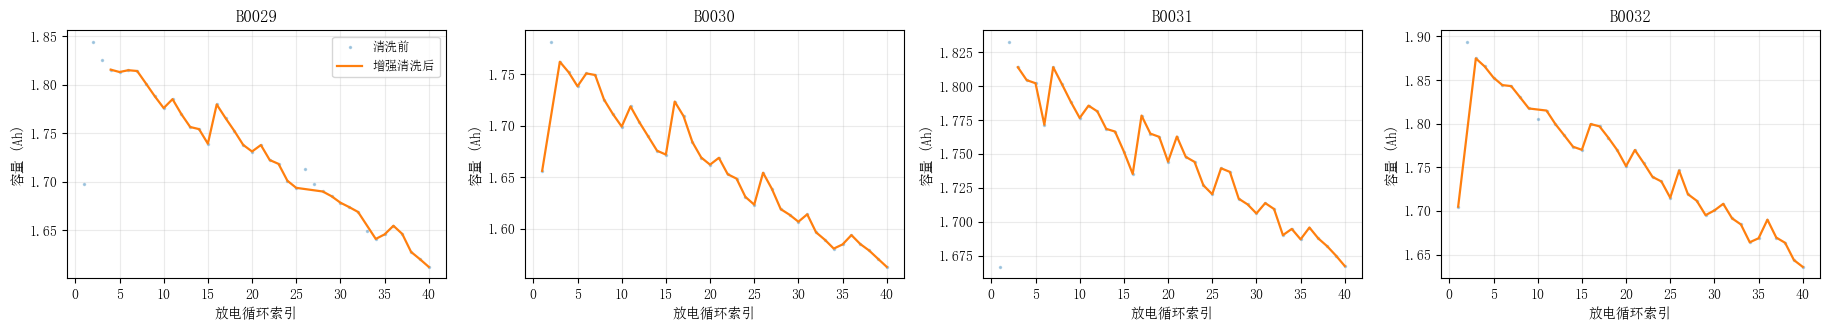

high 温区对比图已保存: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_high_20260330_090958.png


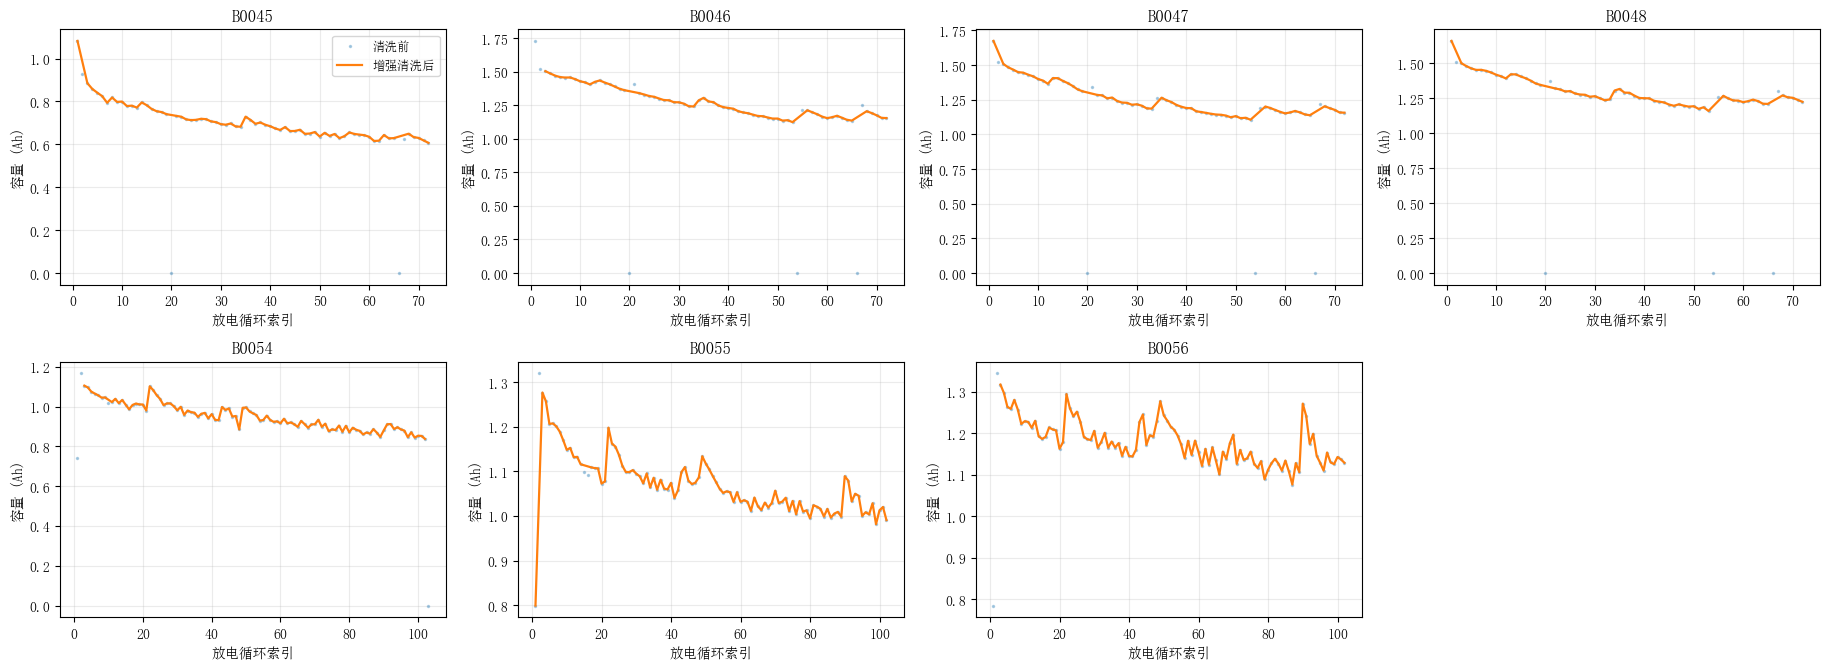

low 温区对比图已保存: C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_low_20260330_090959.png


In [7]:
# 仅主实验训练材料：清洗前后对比（不含G8，且剔除B0053）
train_group_map = {
    'room': ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0033', 'B0034', 'B0036', 'B0038'],
    'high': ['B0029', 'B0030', 'B0031', 'B0032'],
    'low':  ['B0045', 'B0046', 'B0047', 'B0048', 'B0054', 'B0055', 'B0056'],
}
train_ids = train_group_map['room'] + train_group_map['high'] + train_group_map['low']

# 汇总表（便于论文描述）
train_rows = []
for zone, bids in train_group_map.items():
    for bid in bids:
        n_raw = np.nan
        if bid in battery_index:
            df_raw = pd.read_pickle(battery_index[bid])
            if 'Cycle_Type' in df_raw.columns:
                df_raw = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
            n_raw = int(len(df_raw))
        n_clean = int(len(cleaned_data_adv.get(bid, pd.DataFrame()))) if bid in cleaned_data_adv else np.nan
        keep_ratio = (n_clean / n_raw) if (pd.notna(n_raw) and n_raw > 0) else np.nan
        train_rows.append({
            'battery_id': bid,
            'temp_zone': zone,
            'n_raw_discharge': n_raw,
            'n_clean_discharge': n_clean,
            'keep_ratio': keep_ratio,
        })

train_compare_df = pd.DataFrame(train_rows)
print('主实验训练电池数量:', len(train_compare_df))
display(train_compare_df.groupby('temp_zone')['battery_id'].count().reset_index(name='n_batteries'))
display(train_compare_df.head(10))

# 分温区绘图，避免23块电池挤在一张图
plt.rcParams['font.sans-serif'] = ['SimSun', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

for zone in ['room', 'high', 'low']:
    bids = train_group_map[zone]
    n = len(bids)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows), squeeze=False)
    axes = axes.flatten()

    for i, bid in enumerate(bids):
        ax = axes[i]
        if bid not in battery_index:
            ax.set_title(f'{bid} (文件缺失)')
            ax.axis('off')
            continue

        df_raw = pd.read_pickle(battery_index[bid])
        if 'Cycle_Type' in df_raw.columns:
            df_raw = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
        df_raw = _sort_discharge_df(df_raw)

        raw_cap = pd.to_numeric(df_raw.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
        if 'Specific_Index' in df_raw.columns:
            raw_x = pd.to_numeric(df_raw['Specific_Index'], errors='coerce').to_numpy(dtype=float)
        else:
            raw_x = np.arange(len(raw_cap), dtype=float)

        df_adv = cleaned_data_adv.get(bid, pd.DataFrame()).copy()
        df_adv = _sort_discharge_df(df_adv) if len(df_adv) > 0 else df_adv
        adv_cap = pd.to_numeric(df_adv.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
        if len(df_adv) > 0 and 'Specific_Index' in df_adv.columns:
            adv_x = pd.to_numeric(df_adv['Specific_Index'], errors='coerce').to_numpy(dtype=float)
        else:
            adv_x = np.arange(len(adv_cap), dtype=float)

        ax.plot(raw_x, raw_cap, '.', alpha=0.30, markersize=3, label='清洗前')
        ax.plot(adv_x, adv_cap, '-', linewidth=1.6, label='增强清洗后')
        ax.set_title(bid)
        ax.set_xlabel('放电循环索引')
        ax.set_ylabel('容量 (Ah)')
        ax.grid(True, alpha=0.25)
        if i == 0:
            ax.legend(loc='best', fontsize=9)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    fig_zone_path = REPORT_ADV_ROOT / f"main_train_before_after_{zone}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(fig_zone_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'{zone} 温区对比图已保存:', fig_zone_path)

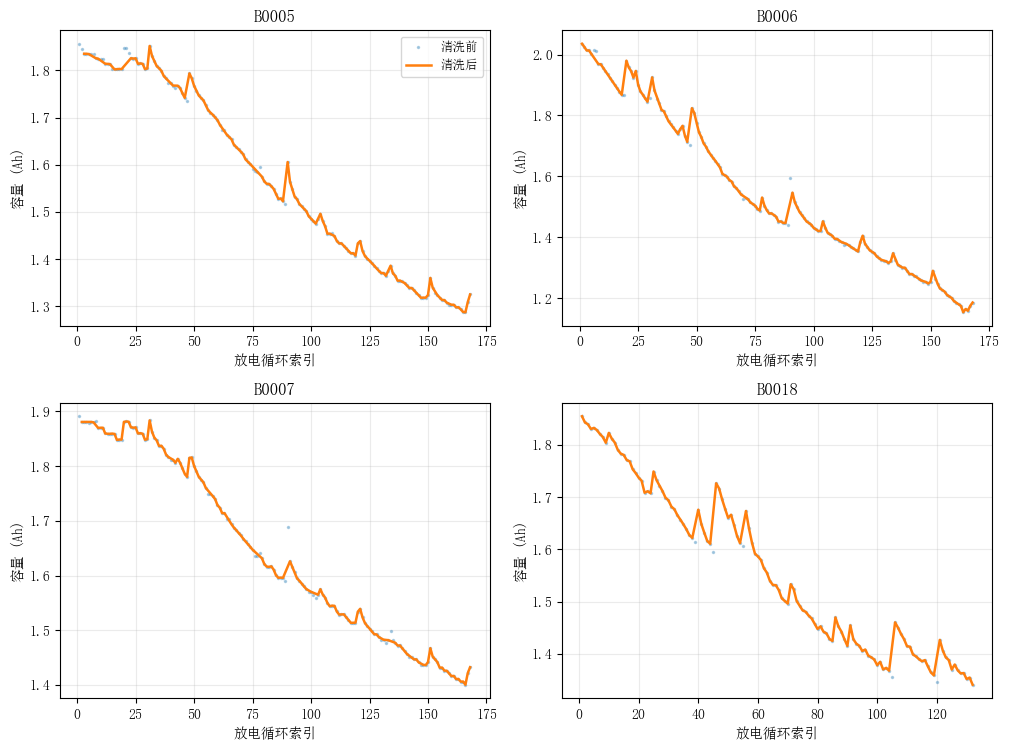

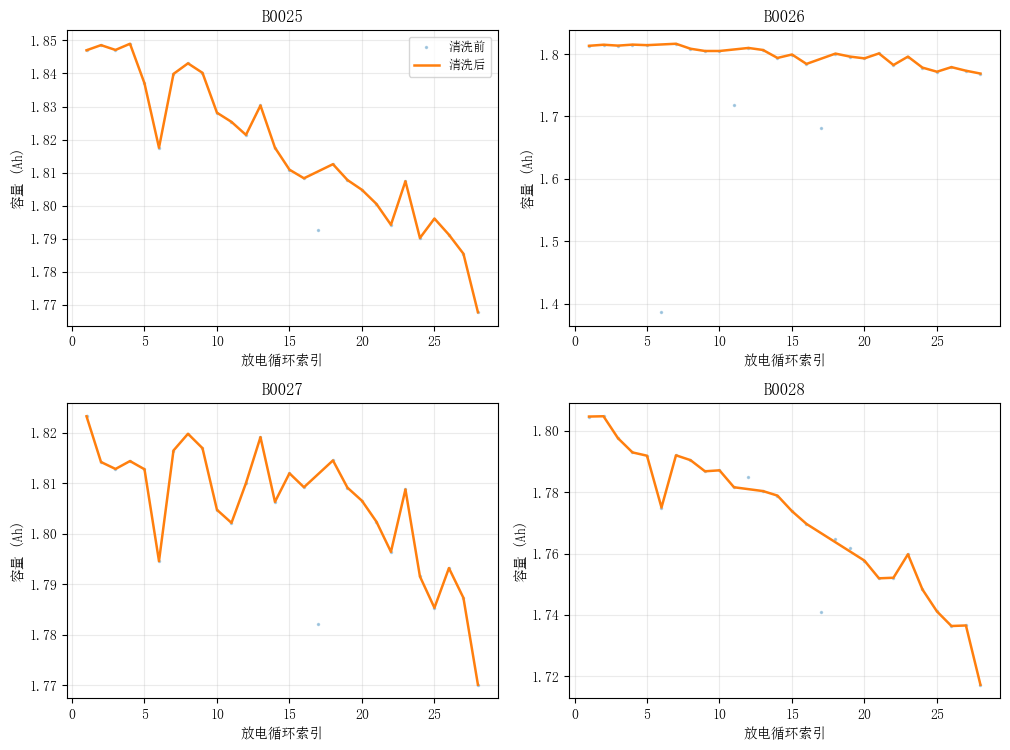

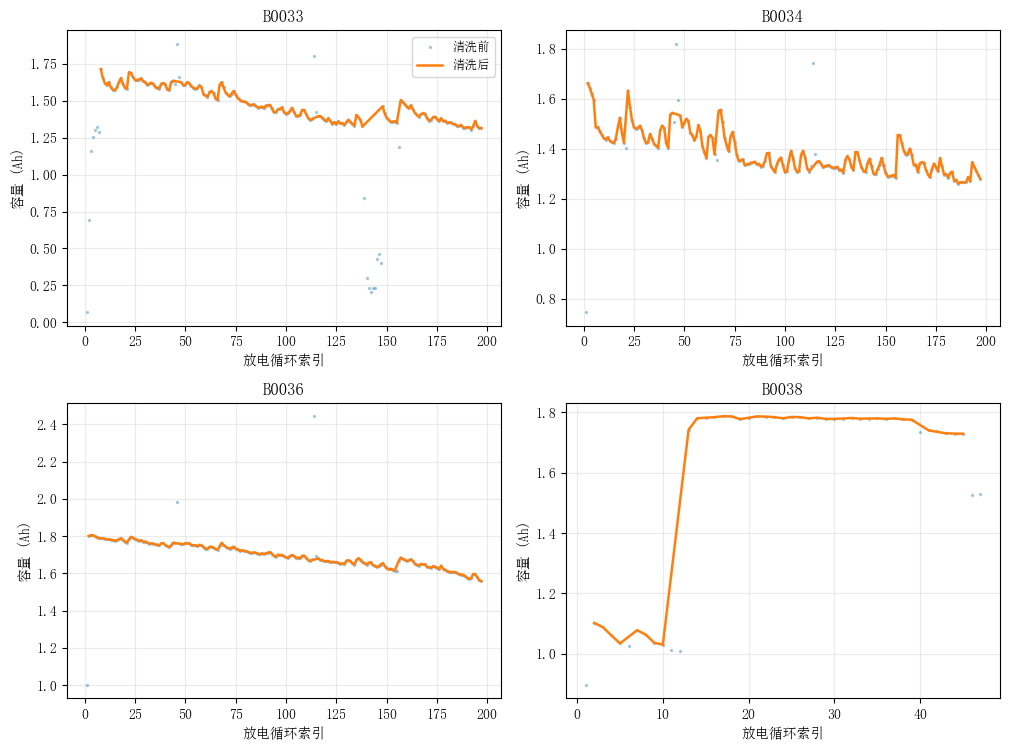

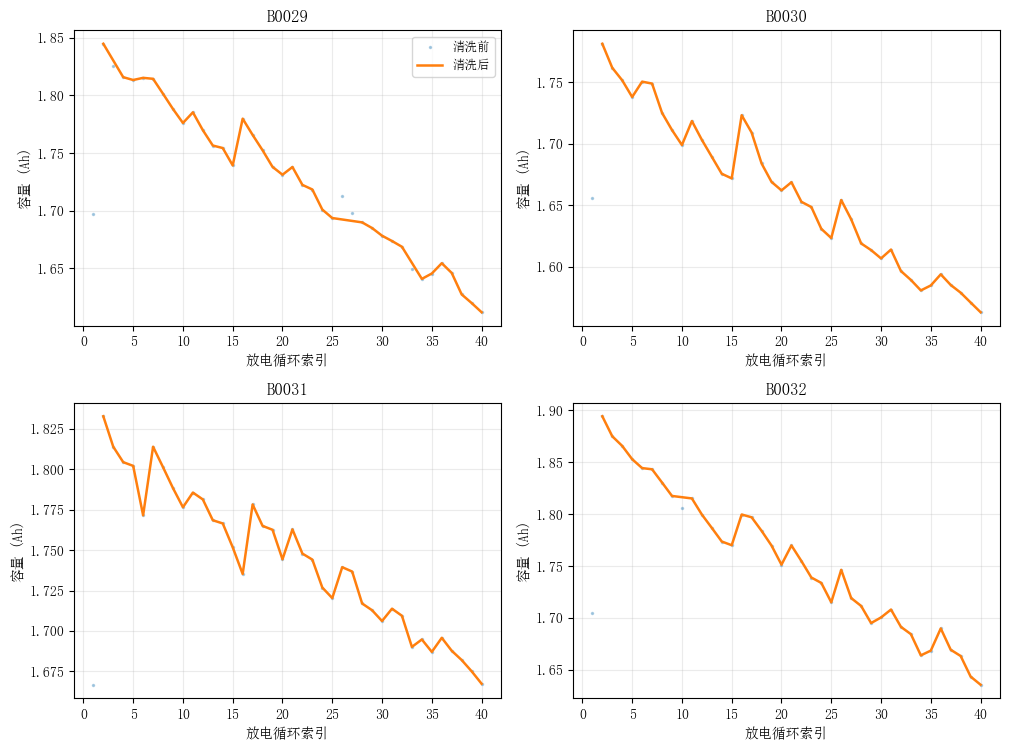

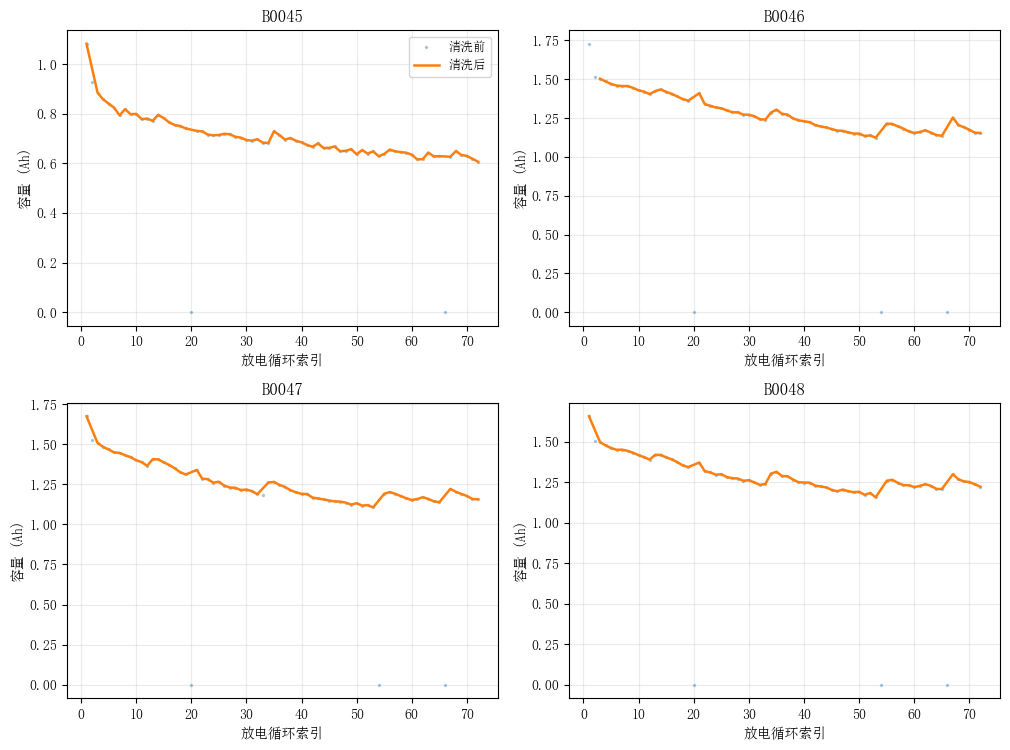

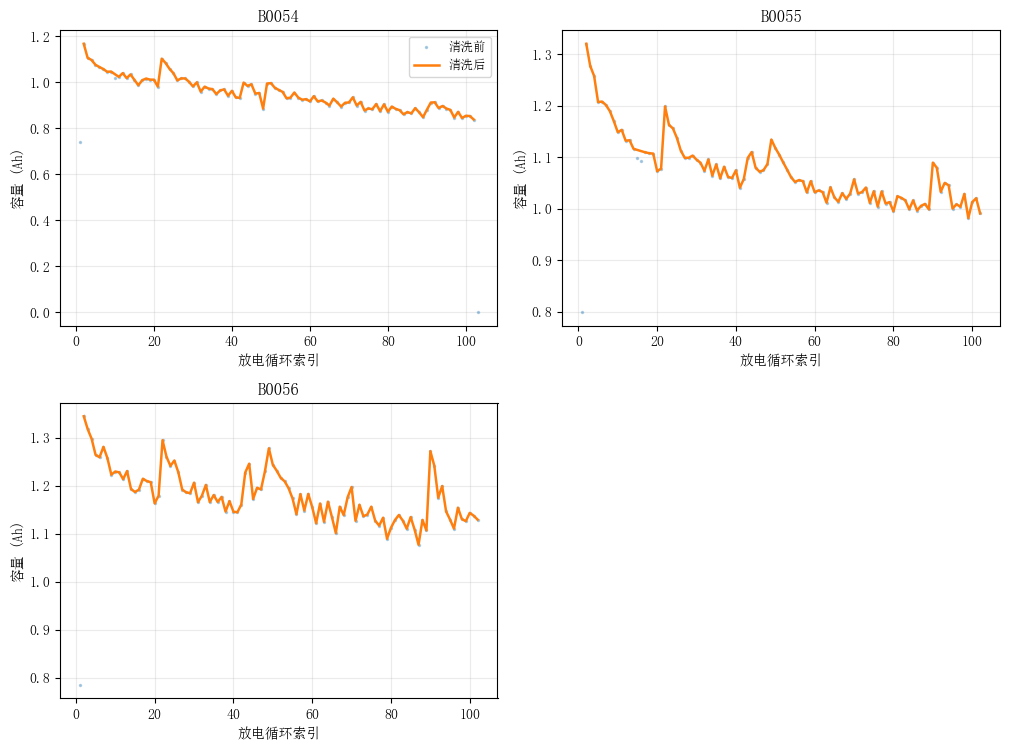

已导出小图数量: 6
 - C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_room_part1_20260330_100652.png
 - C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_room_part2_20260330_100652.png
 - C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_room_part3_20260330_100652.png
 - C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_high_part1_20260330_100652.png
 - C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_low_part1_20260330_100652.png
 - C:\Users\PLUTO\Desktop\battery-rul\results\cleaning_reports\main_train_before_after_low_part2_20260330_100652.png


In [14]:
# 主实验训练材料分图导出（每4块电池一张小图）
import math

# 若上一个单元未运行，补一个主实验分组定义
if 'train_group_map' not in globals():
    train_group_map = {
        'room': ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0033', 'B0034', 'B0036', 'B0038'],
        'high': ['B0029', 'B0030', 'B0031', 'B0032'],
        'low':  ['B0045', 'B0046', 'B0047', 'B0048', 'B0054', 'B0055', 'B0056'],
    }

# 防止当前会话没有排序函数
if '_sort_discharge_df' not in globals():
    def _sort_discharge_df(df):
        if 'Specific_Index' in df.columns:
            sidx = pd.to_numeric(df['Specific_Index'], errors='coerce')
            if sidx.notna().sum() > 0:
                tmp = df.copy()
                tmp['_sidx_num'] = sidx
                tmp = tmp.sort_values('_sidx_num').drop(columns=['_sidx_num'])
                return tmp.reset_index(drop=True)
        return df.reset_index(drop=True)

chunk_size = 4
ts_small = datetime.now().strftime('%Y%m%d_%H%M%S')
small_fig_paths = []

plt.rcParams['font.sans-serif'] = ['SimSun', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

for zone in ['room', 'high', 'low']:
    bids = train_group_map.get(zone, [])
    if len(bids) == 0:
        continue

    n_parts = int(math.ceil(len(bids) / chunk_size))
    for part_idx in range(n_parts):
        sub_bids = bids[part_idx * chunk_size:(part_idx + 1) * chunk_size]
        nrows, ncols = 2, 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(10.2, 7.6), squeeze=False)
        axes = axes.flatten()

        for i, bid in enumerate(sub_bids):
            ax = axes[i]
            if bid not in battery_index:
                ax.set_title(f'{bid} (文件缺失)')
                ax.axis('off')
                continue

            df_raw = pd.read_pickle(battery_index[bid])
            if 'Cycle_Type' in df_raw.columns:
                df_raw = df_raw[df_raw['Cycle_Type'] == 'discharge'].copy()
            df_raw = _sort_discharge_df(df_raw)

            raw_cap = pd.to_numeric(df_raw.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
            if 'Specific_Index' in df_raw.columns:
                raw_x = pd.to_numeric(df_raw['Specific_Index'], errors='coerce').to_numpy(dtype=float)
            else:
                raw_x = np.arange(len(raw_cap), dtype=float)

            if 'cleaned_data_adv' in globals() and bid in cleaned_data_adv:
                df_clean = cleaned_data_adv[bid].copy()
            else:
                # 兼容未运行增强清洗单元时，从train_data读取
                train_path = PROJECT_ROOT / 'data' / 'train_data' / zone / f'{bid}.pkl'
                df_clean = pd.read_pickle(train_path) if train_path.exists() else pd.DataFrame()

            df_clean = _sort_discharge_df(df_clean) if len(df_clean) > 0 else df_clean
            clean_cap = pd.to_numeric(df_clean.get('Capacity', pd.Series(dtype=float)), errors='coerce').to_numpy(dtype=float)
            if len(df_clean) > 0 and 'Specific_Index' in df_clean.columns:
                clean_x = pd.to_numeric(df_clean['Specific_Index'], errors='coerce').to_numpy(dtype=float)
            else:
                clean_x = np.arange(len(clean_cap), dtype=float)

            ax.plot(raw_x, raw_cap, '.', alpha=0.30, markersize=3, label='清洗前')
            ax.plot(clean_x, clean_cap, '-', linewidth=1.8, label='清洗后')
            ax.set_title(bid)
            ax.set_xlabel('放电循环索引')
            ax.set_ylabel('容量 (Ah)')
            ax.grid(True, alpha=0.25)
            if i == 0:
                ax.legend(loc='best', fontsize=9)

        for j in range(len(sub_bids), len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        out_path = REPORT_ADV_ROOT / f'main_train_before_after_{zone}_part{part_idx + 1}_{ts_small}.png'
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.show()
        small_fig_paths.append(str(out_path))

print('已导出小图数量:', len(small_fig_paths))
for p in small_fig_paths:
    print(' -', p)

## 论文3.4可直接引用的写作要点

1. 先给出硬规则与弱规则的定义，并强调"不做强制单调化"。
2. 报告清洗前后样本总量、保留率与异常点剔除数量。
3. 展示典型电池（如 B0049/B0053）清洗前后对比图。
4. 说明清洗后的统一特征表如何对接后续模型训练。